In [1]:
!pip install medmnist -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import medmnist
from medmnist import ChestMNIST
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("MedMNIST version:", medmnist.__version__)

MedMNIST version: 3.0.2


In [3]:
train_data = ChestMNIST(split='train', download=True, size=224)
val_data   = ChestMNIST(split='val',   download=True, size=224)
test_data  = ChestMNIST(split='test',  download=True, size=224)

print(f"Train : {len(train_data)} images")
print(f"Val   : {len(val_data)} images")
print(f"Test  : {len(test_data)} images")

100%|██████████| 3.89G/3.89G [16:47<00:00, 3.86MB/s] 


Train : 78468 images
Val   : 11219 images
Test  : 22433 images


In [4]:
LABELS = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural Thickening", "Hernia"
]
print("Nombre de classes :", len(LABELS))

Nombre de classes : 14


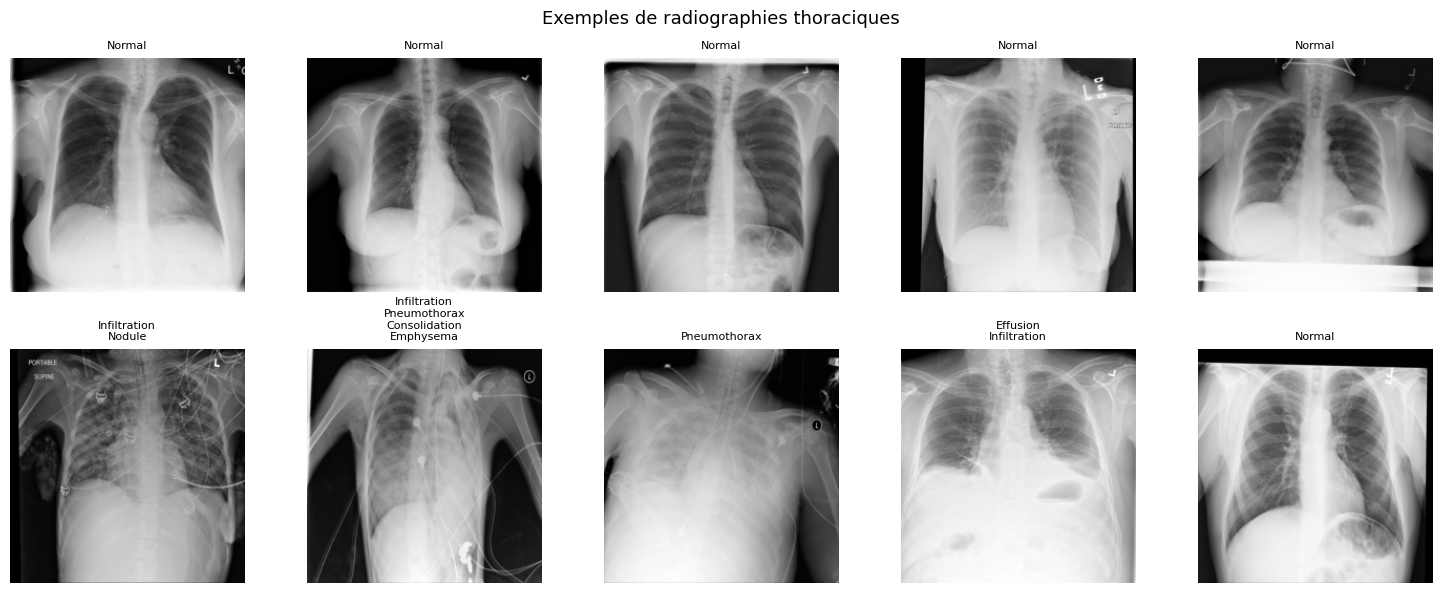

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    img, label = train_data[i]
    ax.imshow(img, cmap='gray')
    pathologies = [LABELS[j] for j, v in enumerate(label) if v == 1]
    ax.set_title('\n'.join(pathologies) if pathologies else "Normal", fontsize=8)
    ax.axis('off')
plt.suptitle("Exemples de radiographies thoraciques", fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\ONGOLO YVAN\AppData\Local\Temp\ipykernel_30104\3729404352.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(LABELS, rotation=45, ha='right')


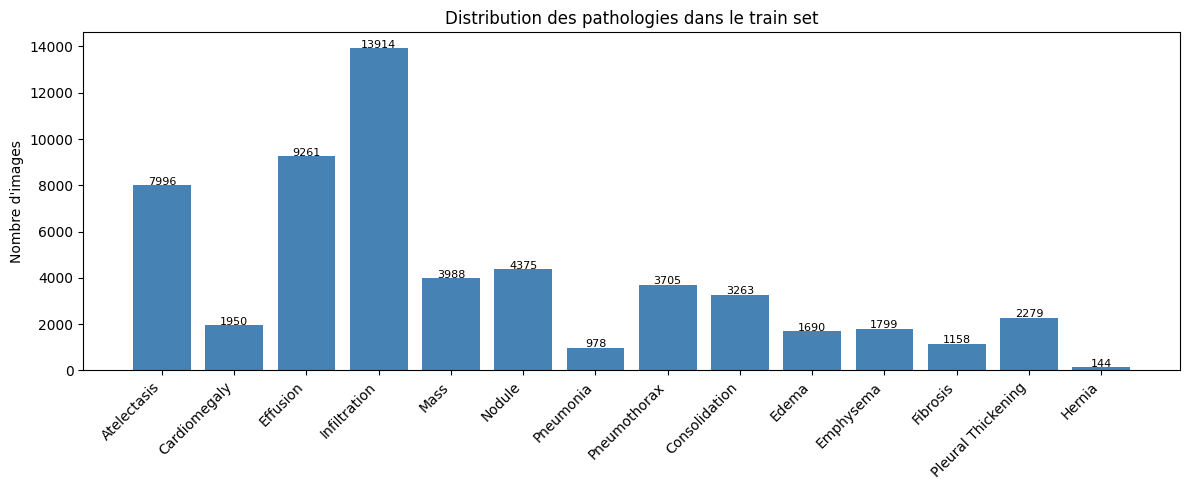

In [6]:
all_labels = np.array([train_data[i][1] for i in range(len(train_data))])

counts = all_labels.sum(axis=0)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(LABELS, counts, color='steelblue')
ax.set_xticklabels(LABELS, rotation=45, ha='right')
ax.set_ylabel("Nombre d'images")
ax.set_title("Distribution des pathologies dans le train set")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(int(count)), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

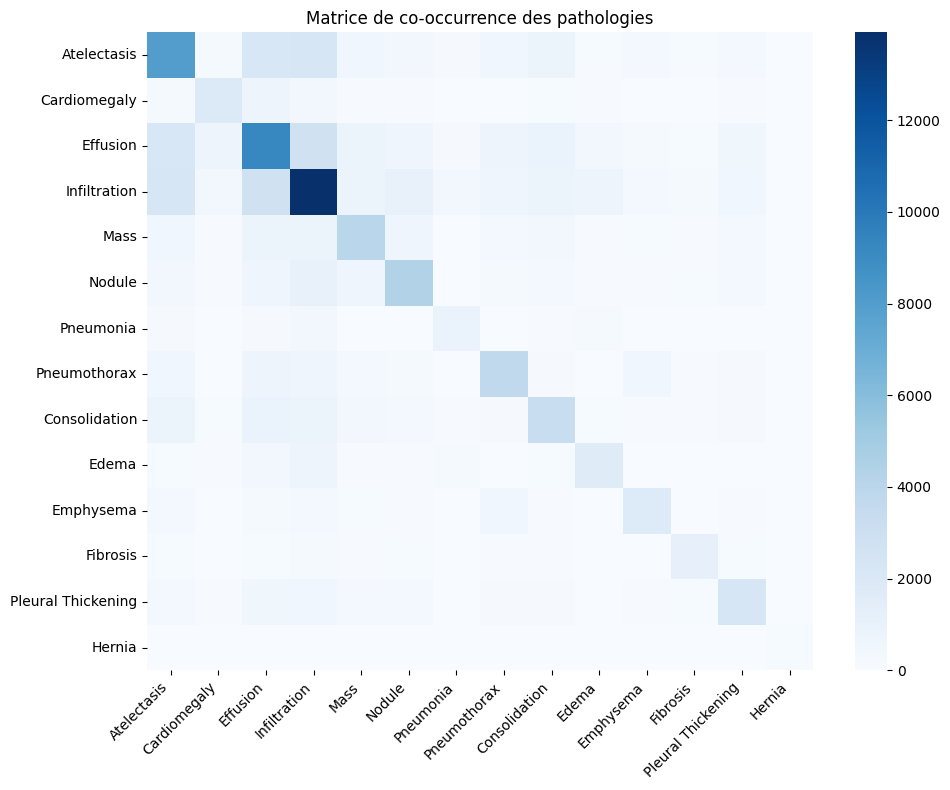

In [7]:
cooccurrence = all_labels.T @ all_labels

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooccurrence, 
            xticklabels=LABELS, 
            yticklabels=LABELS,
            cmap='Blues', 
            annot=False)
ax.set_title("Matrice de co-occurrence des pathologies")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
sample = np.array([np.array(train_data[i][0]) for i in range(1000)])
mean = sample.mean() / 255.0
std  = sample.std()  / 255.0
print(f"Mean pixel : {mean:.4f}")
print(f"Std pixel  : {std:.4f}")
print("\nNote ces deux valeurs, on en aura besoin pour le preprocessing !")

Mean pixel : 0.4983
Std pixel  : 0.2482

Note ces deux valeurs, on en aura besoin pour le preprocessing !
